In [3]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from PIL import Image
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset
import math
import scipy.special
import random as rd
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


### Loading WSI images 

3 classes : 

* ADIMUC : loose non-tumor tissue
* STRMUS : dense non-tumor tissue
* TUMSTU : tumor tissue

We regroup ADIMUC and STRMUS classes into class 0 (non-tumor tissue), TUMSTU images are labelled class 1 (tumor tissue)

We train a simple cnn model to classify the samples into class 0 or class 1, before testing SGR postprocessing

In [4]:
# Replace with your actual dataset path
DATASET_ROOT = 'C:/Users/ejeme/Documents/WSI images for tumor detection in gastrointestinal cancer/'

# Compute mean and std
mean, std = compute_mean_std(DATASET_ROOT)
print("Mean:", mean)
print("Std:", std)

# Your transforms
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_set, val_set, test_set = split_balanced_dataset(
    root=DATASET_ROOT,
    transform=transform,
    train_size=0.5,  # 30% of the smallest class
    val_size=0.3     # 20% of the smallest class
)

# Dataloaders
train_loader = DataLoader(train_set, batch_size=15, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=15, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=15, shuffle=False, num_workers=2)

100%|██████████| 1198/1198 [01:35<00:00, 12.60it/s]

Mean: tensor([0.7801, 0.6251, 0.7518])
Std: tensor([0.1205, 0.1491, 0.1078])


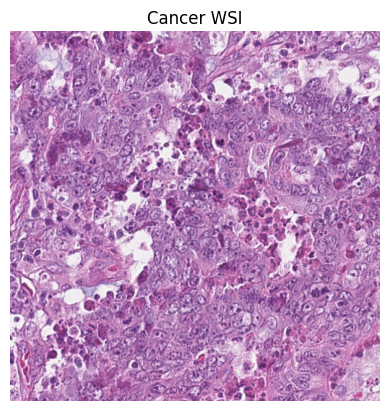

In [16]:
cancer_folder = os.path.join(DATASET_ROOT, 'TUMSTU')
image_files = [f for f in os.listdir(cancer_folder) if f.endswith('.png')]
random_image = rd.choice(image_files)
image_path = os.path.join(cancer_folder, random_image)
img = mpimg.imread(image_path)
plt.imshow(img)
plt.title('Cancer WSI')
plt.axis('off')  # Turn off axis
plt.show()

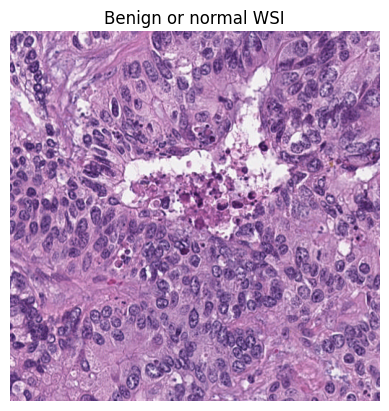

In [24]:
non_cancer_folder = os.path.join(DATASET_ROOT, 'ADIMUC_STRMUS')
image_files = [f for f in os.listdir(cancer_folder) if f.endswith('.png')]
random_image = rd.choice(image_files)
image_path = os.path.join(cancer_folder, random_image)
img = mpimg.imread(image_path)
plt.imshow(img)
plt.title('Benign or normal WSI')
plt.axis('off')  # Turn off axis
plt.show()

In [7]:
next(iter(train_loader))

[tensor([[[[ 1.4021,  1.4021,  1.4021,  ...,  1.4021,  1.4021,  1.4021],
           [ 1.4672,  1.4672,  1.4672,  ...,  1.4672,  1.4672,  1.4672],
           [ 1.5323,  1.5323,  1.4998,  ...,  1.4672,  1.4672,  1.4672],
           ...,
           [ 1.4347,  1.4347,  1.4347,  ...,  1.4347,  1.4347,  1.4347],
           [ 1.4347,  1.4347,  1.4347,  ...,  1.4347,  1.4347,  1.4347],
           [ 1.4347,  1.4347,  1.4347,  ...,  1.4347,  1.4347,  1.4347]],
 
          [[ 2.1995,  2.1995,  2.1995,  ...,  2.1995,  2.1995,  2.1731],
           [ 2.1995,  2.1995,  2.1995,  ...,  2.1995,  2.1995,  2.1731],
           [ 2.1995,  2.1995,  2.1995,  ...,  2.1995,  2.1995,  2.1995],
           ...,
           [ 2.2258,  2.2258,  2.2258,  ...,  2.1995,  2.1995,  2.1995],
           [ 2.2258,  2.2258,  2.2258,  ...,  2.1995,  2.1995,  2.2258],
           [ 2.2258,  2.2258,  2.2258,  ...,  2.1995,  2.1995,  2.2258]],
 
          [[ 1.9018,  1.9018,  1.9018,  ...,  1.8654,  1.8654,  1.8654],
           [ 

In [5]:
train_counts = count_labels(train_set)
val_counts = count_labels(val_set)
test_counts = count_labels(test_set)

print("Train set: ", train_counts)
print("Val set:   ", val_counts)
print("Test set:  ", test_counts)


Train set:  {0: 2000, 1: 2000}
Val set:    {0: 1200, 1: 1200}
Test set:   {0: 4777, 1: 800}


In [6]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))  # Force feature map to 4x4
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)             # Output shape: [B, 32, 4, 4]
        x = x.view(x.size(0), -1)             # Flatten safely: [B, 512]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model
cnn = SmallCNN().to(device)

In [11]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)

# Training Loop
num_epochs = 15
for epoch in range(num_epochs):
    cnn.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate cnn at the end of current epoch
    cnn.eval()
    correct = 0
    total = 0
    print('TESTING')
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(cnn.state_dict(), "C:/Users/ejeme/Documents/python_repos/WSI_histo/cnn_wsi_binary_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 267/267 [00:26<00:00,  9.89it/s]


Epoch [1/15], Loss: 0.3672
Train Accuracy: 86.65%
TESTING
Validation Accuracy: 91.83%
TRAINING EPOCH 1


100%|██████████| 267/267 [00:25<00:00, 10.30it/s]


Epoch [2/15], Loss: 0.1954
Train Accuracy: 92.72%
TESTING
Validation Accuracy: 92.67%
TRAINING EPOCH 2


...

Epoch [13/15], Loss: 0.1697
Train Accuracy: 93.75%
TESTING
Validation Accuracy: 93.50%
TRAINING EPOCH 13


100%|██████████| 267/267 [00:26<00:00, 10.26it/s]


Epoch [14/15], Loss: 0.1698
Train Accuracy: 93.78%
TESTING
Validation Accuracy: 93.50%
TRAINING EPOCH 14


100%|██████████| 267/267 [00:25<00:00, 10.48it/s]


Epoch [15/15], Loss: 0.1697
Train Accuracy: 93.78%
TESTING
Validation Accuracy: 93.50%


### Retrieving Softmax Response, Predicted class and True class for all samples in val and test sets

In [7]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("C:/Users/ejeme/Documents/python_repos/WSI_histo/cnn_wsi_binary_epoch0.pth")
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [8]:
sgr_dico_val = prepare_sgr_dico(val_loader, model = cnn, device = device, T = 1)
sgr_val_set = pd.DataFrame(sgr_dico_val)

100%|██████████| 160/160 [00:19<00:00,  8.34it/s]


In [9]:
sgr_dico_test = prepare_sgr_dico(test_loader, model = cnn, device = device, T = 1)
sgr_test_set = pd.DataFrame(sgr_dico_test)

100%|██████████| 372/372 [00:35<00:00, 10.60it/s]


In [10]:
sgr_set = pd.concat([sgr_val_set, sgr_test_set]).reset_index(drop=True)
pickle.dump(sgr_set, open('sgr_set_cnn','wb'))

In [11]:
sgr_set.sort_values('kappa')

,y_true,y_pred,kappa
3887,0.0,1.0,0.500071
5908,0.0,0.0,0.500384
7651,0.0,0.0,0.500489
1430,1.0,1.0,0.500708
1408,0.0,0.0,0.500901
...,...,...,...
825,0.0,0.0,0.999976
31,0.0,0.0,0.999977
7649,0.0,0.0,0.999977
2718,0.0,0.0,0.999978


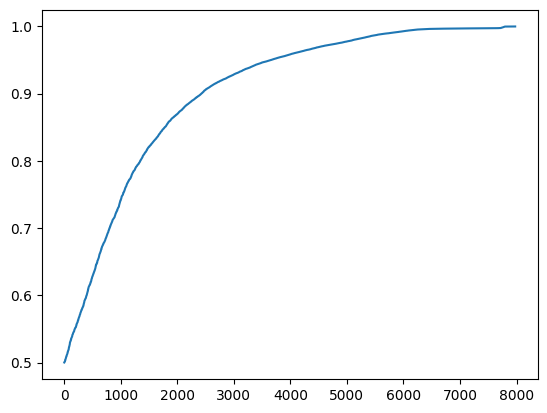

In [12]:
plt.plot(list(sgr_set.sort_values('kappa').kappa))
plt.show()